# Lekcja 10: NumPy i podstawy pracy z tablicami

# 1. Czym jest NumPy i dlaczego jest kluczowy w Data Science

In [22]:
# PRZYKŁAD 1: Instalacja i import NumPy

# Instalacja NumPy (w Google Colab już zainstalowany)
# !pip install numpy
# Import NumPy - konwencja 'np'

import numpy as np
# Sprawdzenie wersji
print(f"Wersja NumPy: {np.__version__}")
# Wynik: Wersja NumPy: 1.24.3 (lub nowsza)
# Informacje o konfiguracji NumPy
np.show_config()

Wersja NumPy: 2.4.4
{
  "Compilers": {
    "c": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35225",
      "commands": "cl"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.4",
      "commands": "cython"
    },
    "c++": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35225",
      "commands": "cl"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    },
    "build": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "scipy-openblas",
      "found": true,
      "version": "0.3.31.188.0",
      "detection method": "pkgconfig",
      "include directory": "C:/Users/runneradmin/AppData/Local/Temp/cibw-run-ucojyb64/cp314-win_amd64/build/venv/Lib/site-packages/scipy_openblas64/in

In [28]:
# PRZYKŁAD 2: Listy vs Tablice NumPy - porównanie wydajności

import numpy as np
import time

# Tworzenie dużej listy Pythonowej
python_list = list(range(1000000))

# Tworzenie tablicy NumPy
numpy_array = np.array(range(1000000))

# Test 1: Podwojenie wszystkich elementów - LISTA
start = time.time()
doubled_list = [x * 2 for x in python_list]
list_time = time.time() - start
print(f"Czas dla listy Python: {list_time:.4f} s")

# Test 2: Podwojenie wszystkich elementów - NUMPY
start = time.time()
doubled_array = numpy_array * 2
numpy_time = time.time() - start
print(f"Czas dla tablicy NumPy: {numpy_time:.4f} s")

# Porównanie
speedup = list_time / numpy_time
print(f"\nNumPy jest {speedup:.1f}x szybszy!")

# Porównanie rozmiaru w pamięci
import sys
list_size = sys.getsizeof(python_list)
array_size = numpy_array.nbytes
print(f"\nRozmiar listy: {list_size / 1024:.1f} KB")
print(f"Rozmiar tablicy NumPy: {array_size / 1024:.1f} KB")
print(f"Oszczędność pamięci: {(1 - array_size/list_size)*100:.1f}%")


Czas dla listy Python: 0.0729 s
Czas dla tablicy NumPy: 0.0029 s

NumPy jest 24.9x szybszy!

Rozmiar listy: 7812.6 KB
Rozmiar tablicy NumPy: 7812.5 KB
Oszczędność pamięci: 0.0%


In [24]:
# PRZYKŁAD 3: Tworzenie tablic NumPy - różne sposoby

import numpy as np

# 1. Z listy Pythonowej
arr_from_list = np.array([1, 2, 3, 4, 5])
print("Z listy:", arr_from_list)
print("Typ:", type(arr_from_list))
print("Dtype:", arr_from_list.dtype) # int64 na większości systemów

# 2. Z zagnieżdżonej listy (tablica 2D)
arr_2d = np.array([[1, 2, 3], [4, 5, 6]])
print("\nTablica 2D:\n", arr_2d)
print("Shape:", arr_2d.shape) # (2, 3) - 2 wiersze, 3 kolumny
print("Wymiary:", arr_2d.ndim) # 2 - dwuwymiarowa

# 3. Tablice wypełnione zerami
zeros = np.zeros(5)
print("\nZera:", zeros)
zeros_2d = np.zeros((3, 4)) # 3 wiersze, 4 kolumny
print("Zera 2D:\n", zeros_2d)

# 4. Tablice wypełnione jedynkami
ones = np.ones((2, 3))
print("\nJedynki:\n", ones)

# 5. Tablice wypełnione konkretną wartością
full = np.full((2, 2), 7)
print("\nWypełnione 7:\n", full)

# 6. Sekwencje - podobne do range()
sequence = np.arange(0, 10, 2) # start, stop, step
print("\nSekwencja:", sequence) # [0 2 4 6 8]

# 7. Równoodległe wartości
linspace = np.linspace(0, 1, 5) # 5 wartości od 0 do 1
print("Linspace:", linspace) # [0. 0.25 0.5 0.75 1. ]

# 8. Macierz identyczności
identity = np.eye(3)
print("\nMacierz identyczności:\n", identity)

# 9. Losowe wartości
random_vals = np.random.rand(5) # 5 losowych wartości [0, 1)
print("\nLosowe [0,1):", random_vals)
random_ints = np.random.randint(1, 100, size=10) # 10 losowych int z [1,100)
print("Losowe int:", random_ints)

# 10. Określanie typu danych
float_array = np.array([1, 2, 3], dtype=np.float32)
print("\nFloat32:", float_array, float_array.dtype)

Z listy: [1 2 3 4 5]
Typ: <class 'numpy.ndarray'>
Dtype: int64

Tablica 2D:
 [[1 2 3]
 [4 5 6]]
Shape: (2, 3)
Wymiary: 2

Zera: [0. 0. 0. 0. 0.]
Zera 2D:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Jedynki:
 [[1. 1. 1.]
 [1. 1. 1.]]

Wypełnione 7:
 [[7 7]
 [7 7]]

Sekwencja: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]

Macierz identyczności:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Losowe [0,1): [0.5675762  0.75958277 0.71012301 0.84527575 0.54381472]
Losowe int: [56 51 76 36 88  8 38 53 74  4]

Float32: [1. 2. 3.] float32


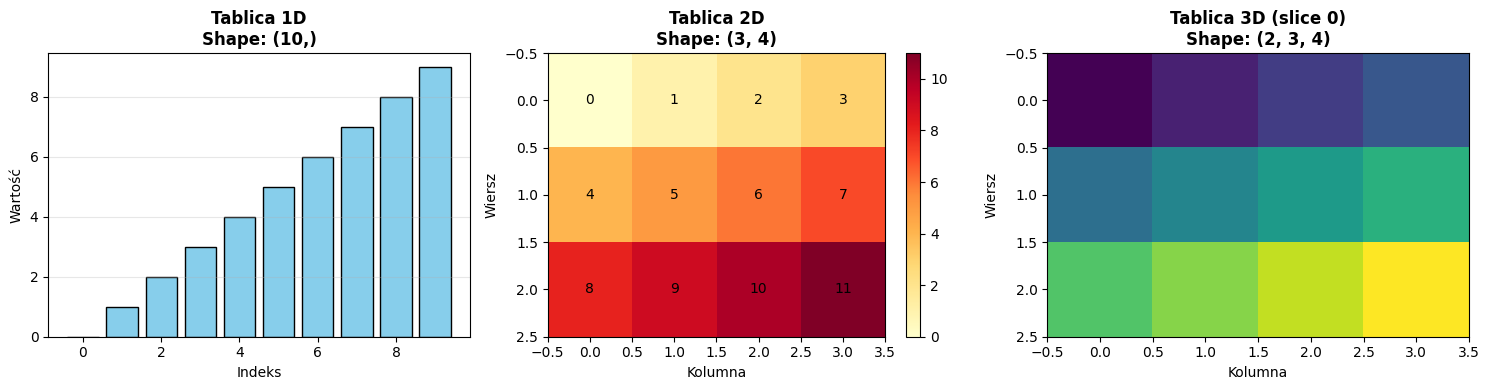

Tablica 1D: 1 wymiar, shape: (10,)
Tablica 2D: 2 wymiary, shape: (3, 4)
Tablica 3D: 3 wymiary, shape: (2, 3, 4)


In [1]:
# Wizualizacja: Kształty tablic

import numpy as np
import matplotlib.pyplot as plt

# Tworzenie tablic różnych wymiarów
arr_1d = np.arange(10)
arr_2d = np.arange(12).reshape(3, 4)
arr_3d = np.arange(24).reshape(2, 3, 4)

# Wizualizacja
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1D array
axes[0].bar(range(len(arr_1d)), arr_1d, color='skyblue', edgecolor='black')
axes[0].set_title(f'Tablica 1D\nShape: {arr_1d.shape}', fontsize=12, 
fontweight='bold')
axes[0].set_xlabel('Indeks')
axes[0].set_ylabel('Wartość')
axes[0].grid(axis='y', alpha=0.3)

# 2D array - heatmap
im2 = axes[1].imshow(arr_2d, cmap='YlOrRd', aspect='auto')
axes[1].set_title(f'Tablica 2D\nShape: {arr_2d.shape}', fontsize=12, 
fontweight='bold')
axes[1].set_xlabel('Kolumna')
axes[1].set_ylabel('Wiersz')
plt.colorbar(im2, ax=axes[1])

# Dodanie wartości w komórkach
for i in range(arr_2d.shape[0]):
    for j in range(arr_2d.shape[1]):
        axes[1].text(j, i, arr_2d[i, j], ha='center', va='center', color='black')
        
# 3D array - pokazanie jednego slice
axes[2].imshow(arr_3d[0], cmap='viridis', aspect='auto')
axes[2].set_title(f'Tablica 3D (slice 0)\nShape: {arr_3d.shape}', 
fontsize=12, fontweight='bold')
axes[2].set_xlabel('Kolumna')
axes[2].set_ylabel('Wiersz')

plt.tight_layout()
plt.show()

print(f"Tablica 1D: {arr_1d.ndim} wymiar, shape: {arr_1d.shape}")
print(f"Tablica 2D: {arr_2d.ndim} wymiary, shape: {arr_2d.shape}")
print(f"Tablica 3D: {arr_3d.ndim} wymiary, shape: {arr_3d.shape}")

# 2. Indeksowanie i wycinanie tablic (slicing)

In [2]:
# Przykład 1: Indeksowanie 1D - podstawy

import numpy as np

# Tworzenie tablicy
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

# Pojedynczy element
print("Element 0:", arr[0])      # 10
print("Element 3:", arr[3])      # 40
print("Ostatni:", arr[-1])       # 90
print("Przedostatni:", arr[-2])  # 80

# Slicing: arr[start:stop:step]
print("\nPierwsze 3:", arr[:3])        # [10 20 30]
print("Od 3 do końca:", arr[3:])       # [40 50 60 70 80 90]
print("Od 2 do 6:", arr[2:6])          # [30 40 50 60]
print("Co drugi:", arr[::2])           # [10 30 50 70 90]
print("Odwrócone:", arr[::-1])         # [90 80 70 60 50 40 30 20 10]

# Slicing zwraca VIEW, nie kopię!
sub_arr = arr[2:5]
sub_arr[0] = 999
print("\nOryginal po zmianie:", arr)  # [10 20 999 40 50 ...]
# Element został zmieniony w oryginalnej tablicy!

# Aby uzyskać kopię:
copy_arr = arr[2:5].copy()
copy_arr[0] = 111
print("Original bez zmian:", arr)     # Nie zmienia się

Element 0: 10
Element 3: 40
Ostatni: 90
Przedostatni: 80

Pierwsze 3: [10 20 30]
Od 3 do końca: [40 50 60 70 80 90]
Od 2 do 6: [30 40 50 60]
Co drugi: [10 30 50 70 90]
Odwrócone: [90 80 70 60 50 40 30 20 10]

Oryginal po zmianie: [ 10  20 999  40  50  60  70  80  90]
Original bez zmian: [ 10  20 999  40  50  60  70  80  90]


In [3]:
# Przykład 2: Indeksowanie 2D - wiersze i kolumny

import numpy as np

# Tablica 2D - dane temperatury (dni x godziny)
temperatures = np.array([
    [15, 18, 22, 25, 23, 20, 17],  # Dzień 1
    [14, 17, 21, 24, 22, 19, 16],  # Dzień 2
    [16, 19, 23, 26, 24, 21, 18],  # Dzień 3
    [13, 16, 20, 23, 21, 18, 15]   # Dzień 4
])

print("Shape:", temperatures.shape)  # (4, 7) - 4 dni, 7 pomiarów

# Pojedynczy element: arr[row, col]
print("\nTemp dzień 0, godzina 3:", temperatures[0, 3])  # 25

# Cały wiersz (dzień)
print("Dzień 2:", temperatures[2])  # [16 19 23 26 24 21 18]

# Cała kolumna (godzina) - trzeba użyć :
print("Godzina 3 wszystkie dni:", temperatures[:, 3])  # [25 24 26 23]

# Fragment tablicy
print("\nPierwsze 2 dni, pierwsze 3 godziny:")
print(temperatures[:2, :3])
# [[15 18 22]
#  [14 17 21]]

# Ostatni wiersz, ostatnie 3 kolumny
print("\nOstatni dzień, ostatnie 3 pomiary:")
print(temperatures[-1, -3:])  # [18 15]

# Co drugi wiersz, co druga kolumna
print("\nCo drugi dzień i pomiar:")
print(temperatures[::2, ::2])
# [[15 22 23 17]
#  [16 23 24 18]]

Shape: (4, 7)

Temp dzień 0, godzina 3: 25
Dzień 2: [16 19 23 26 24 21 18]
Godzina 3 wszystkie dni: [25 24 26 23]

Pierwsze 2 dni, pierwsze 3 godziny:
[[15 18 22]
 [14 17 21]]

Ostatni dzień, ostatnie 3 pomiary:
[21 18 15]

Co drugi dzień i pomiar:
[[15 22 23 17]
 [16 23 24 18]]


In [5]:
# Przykład 3: Indeksowanie warunkowe (boolean indexing)

import numpy as np

# Dane: wyniki testów studentów
scores = np.array([45, 78, 92, 34, 88, 56, 91, 23, 67, 85])

# Warunek zwraca tablicę boolean
high_scores_mask = scores >= 80
print("Maska (scores >= 80):", high_scores_mask)
# [False False  True False  True False  True False False  True]

# Użycie maski do filtrowania
high_scores = scores[high_scores_mask]
print("Wysokie wyniki:", high_scores)  # [92 88 91 85]

# Krótsza wersja (bez zmiennej)
print("Niskie wyniki (<50):", scores[scores < 50])  # [45 34 23]

# Złożone warunki - AND (&), OR (|), NOT (~)
medium_scores = scores[(scores >= 60) & (scores < 80)]
print("Średnie wyniki [60-80):", medium_scores)  # [78 67]

# Modyfikacja przez warunek
scores_copy = scores.copy()
scores_copy[scores_copy < 50] = 50  # Podniesienie do 50
print("Po podniesieniu min do 50:", scores_copy)
# [50 78 92 50 88 56 91 50 67 85]

# Zliczanie
num_passed = np.sum(scores >= 60)  # True = 1, False = 0
print(f"\nLiczba zdających (>=60): {num_passed}")
print(f"Procent zdających: {num_passed / len(scores) * 100:.1f}%")

Maska (scores >= 80): [False False  True False  True False  True False False  True]
Wysokie wyniki: [92 88 91 85]
Niskie wyniki (<50): [45 34 23]
Średnie wyniki [60-80): [78 67]
Po podniesieniu min do 50: [50 78 92 50 88 56 91 50 67 85]

Liczba zdających (>=60): 6
Procent zdających: 60.0%


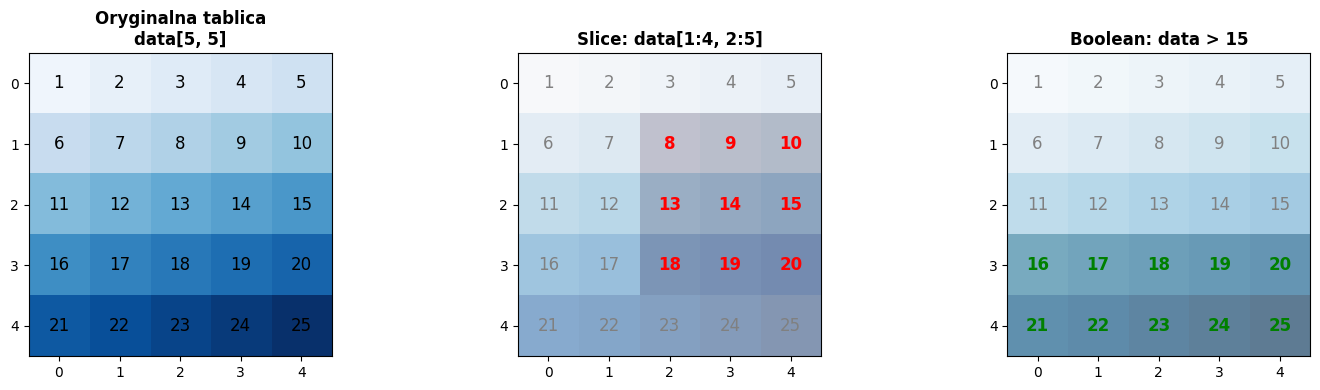

Fragment data[1:4, 2:5]:
[[ 8  9 10]
 [13 14 15]
 [18 19 20]]

Wartości > 15:
[16 17 18 19 20 21 22 23 24 25]


In [6]:
# Wizualizacja: Indeksowanie 2D

import numpy as np
import matplotlib.pyplot as plt

# Tablica przykładowa
data = np.arange(1, 26).reshape(5, 5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Oryginalna tablica
im1 = axes[0].imshow(data, cmap='Blues', vmin=0, vmax=25)
axes[0].set_title('Oryginalna tablica\ndata[5, 5]', fontweight='bold')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, data[i, j], ha='center', va='center', fontsize=12)
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))

# Fragment: data[1:4, 2:5]
highlighted = np.zeros((5, 5))
highlighted[1:4, 2:5] = 1
im2 = axes[1].imshow(highlighted, cmap='Reds', alpha=0.3, vmin=0, vmax=1)
axes[1].imshow(data, cmap='Blues', alpha=0.5, vmin=0, vmax=25)
axes[1].set_title('Slice: data[1:4, 2:5]', fontweight='bold')
for i in range(5):
    for j in range(5):
        color = 'red' if (1 <= i < 4 and 2 <= j < 5) else 'gray'
        weight = 'bold' if (1 <= i < 4 and 2 <= j < 5) else 'normal'
        axes[1].text(j, i, data[i, j], ha='center', va='center',fontsize=12, color=color, fontweight=weight)
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))

# Warunek: data > 15
mask = data > 15
im3 = axes[2].imshow(mask, cmap='Greens', alpha=0.3, vmin=0, vmax=1)
axes[2].imshow(data, cmap='Blues', alpha=0.5, vmin=0, vmax=25)
axes[2].set_title('Boolean: data > 15', fontweight='bold')
for i in range(5):
    for j in range(5):
        color = 'green' if data[i, j] > 15 else 'gray'
        weight = 'bold' if data[i, j] > 15 else 'normal'
        axes[2].text(j, i, data[i, j], ha='center', va='center',fontsize=12, color=color, fontweight=weight)
axes[2].set_xticks(range(5))
axes[2].set_yticks(range(5))

plt.tight_layout()
plt.show()

print("Fragment data[1:4, 2:5]:")
print(data[1:4, 2:5])
print("\nWartości > 15:")
print(data[data > 15])

# 3. Operacje wektorowe i funkcje uniwersalne

In [7]:
# Przykład 1: Podstawowe operacje arytmetyczne

import numpy as np

# Tworzenie tablic
prices = np.array([100, 250, 75, 320, 180])
quantities = np.array([5, 2, 10, 3, 7])

print("Ceny:", prices)
print("Ilości:", quantities)

# Operacje element po elemencie
total_values = prices * quantities
print("\nWartości (cena * ilość):", total_values)
# [500 500 750 960 1260]

# Operacje ze skalarami
prices_with_vat = prices * 1.23  # Dodanie 23% VAT
print("Ceny z VAT:", prices_with_vat)

discounted = prices - 50  # Rabat 50 zł
print("Po rabacie 50zł:", discounted)

# Wszystkie podstawowe operacje
a = np.array([10, 20, 30, 40])
b = np.array([1, 2, 3, 4])

print("\n--- Operacje matematyczne ---")
print("a + b =", a + b)      # [11 22 33 44]
print("a - b =", a - b)      # [9 18 27 36]
print("a * b =", a * b)      # [10 40 90 160]
print("a / b =", a / b)      # [10. 10. 10. 10.]
print("a // b =", a // b)    # [10 10 10 10] - dzielenie całkowite
print("a % b =", a % b)      # [0 0 0 0] - reszta z dzielenia
print("a ** b =", a ** b)    # [10 400 27000 2560000] - potęgowanie

# Porównania - zwracają tablice boolean
print("\n--- Porównania ---")
print("a > 25:", a > 25)     # [False False  True  True]
print("a == 30:", a == 30)   # [False False  True False]

Ceny: [100 250  75 320 180]
Ilości: [ 5  2 10  3  7]

Wartości (cena * ilość): [ 500  500  750  960 1260]
Ceny z VAT: [123.   307.5   92.25 393.6  221.4 ]
Po rabacie 50zł: [ 50 200  25 270 130]

--- Operacje matematyczne ---
a + b = [11 22 33 44]
a - b = [ 9 18 27 36]
a * b = [ 10  40  90 160]
a / b = [10. 10. 10. 10.]
a // b = [10 10 10 10]
a % b = [0 0 0 0]
a ** b = [     10     400   27000 2560000]

--- Porównania ---
a > 25: [False False  True  True]
a == 30: [False False  True False]


In [8]:
# Przykład 2: Funkcje matematyczne (ufuncs)

import numpy as np

# Dane: ceny akcji przez 10 dni
stock_prices = np.array([100, 105, 102, 108, 107, 112, 109, 115, 118, 120])

# Funkcje matematyczne
print("Ceny:", stock_prices)
print("Pierwiastek:", np.sqrt(stock_prices))
print("Kwadrat:", np.square(stock_prices))
print("Log naturalny:", np.log(stock_prices))
print("Exp:", np.exp(np.array([0, 1, 2])))  # e^x

# Funkcje trygonometryczne (kąty w radianach)
angles = np.array([0, np.pi/4, np.pi/2, np.pi])
print("\nKąty:", angles)
print("Sin:", np.sin(angles))
print("Cos:", np.cos(angles))

# Zaokrąglanie
values = np.array([1.2, 2.5, 3.7, 4.1])
print("\nWartości:", values)
print("Round:", np.round(values))    # [1. 2. 4. 4.]
print("Floor:", np.floor(values))    # [1. 2. 3. 4.]
print("Ceil:", np.ceil(values))      # [2. 3. 4. 5.]

# Wartość bezwzględna
returns = np.array([5, -3, 8, -2, 10, -7])
print("\nZwroty:", returns)
print("Abs:", np.abs(returns))       # [5 3 8 2 10 7]

# Przycinanie wartości (clip)
clipped = np.clip(stock_prices, 105, 115)
print("\nClip [105, 115]:", clipped)
# Wartości < 105 → 105, wartości > 115 → 115

Ceny: [100 105 102 108 107 112 109 115 118 120]
Pierwiastek: [10.         10.24695077 10.09950494 10.39230485 10.34408043 10.58300524
 10.44030651 10.72380529 10.86278049 10.95445115]
Kwadrat: [10000 11025 10404 11664 11449 12544 11881 13225 13924 14400]
Log naturalny: [4.60517019 4.65396035 4.62497281 4.68213123 4.67282883 4.71849887
 4.69134788 4.74493213 4.77068462 4.78749174]
Exp: [1.         2.71828183 7.3890561 ]

Kąty: [0.         0.78539816 1.57079633 3.14159265]
Sin: [0.00000000e+00 7.07106781e-01 1.00000000e+00 1.22464680e-16]
Cos: [ 1.00000000e+00  7.07106781e-01  6.12323400e-17 -1.00000000e+00]

Wartości: [1.2 2.5 3.7 4.1]
Round: [1. 2. 4. 4.]
Floor: [1. 2. 3. 4.]
Ceil: [2. 3. 4. 5.]

Zwroty: [ 5 -3  8 -2 10 -7]
Abs: [ 5  3  8  2 10  7]

Clip [105, 115]: [105 105 105 108 107 112 109 115 115 115]


In [10]:
# Przykład 3: Agregacje i statystyki

import numpy as np

# Dane: oceny studentów z 5 egzaminów
exam_scores = np.array([
    [85, 78, 92, 88, 76],  # Student 1
    [90, 85, 88, 92, 89],  # Student 2
    [78, 72, 85, 80, 75],  # Student 3
    [92, 88, 95, 90, 93],  # Student 4
    [67, 70, 75, 72, 68]   # Student 5
])

print("Oceny studentów (5 studentów x 5 egzaminów):")
print(exam_scores)

# Podstawowe statystyki - cała tablica
print("\n--- Statystyki globalne ---")
print("Średnia wszystkich ocen:", np.mean(exam_scores))
print("Mediana:", np.median(exam_scores))
print("Odchylenie std:", np.std(exam_scores))
print("Minimum:", np.min(exam_scores))
print("Maksimum:", np.max(exam_scores))
print("Suma:", np.sum(exam_scores))

# Statystyki per student (axis=1 - wzdłuż wierszy)
print("\n--- Średnie per student ---")
student_means = np.mean(exam_scores, axis=1)
for i, avg in enumerate(student_means):
    print(f"Student {i+1}: {avg:.1f}")

# Statystyki per egzamin (axis=0 - wzdłuż kolumn)
print("\n--- Średnie per egzamin ---")
exam_means = np.mean(exam_scores, axis=0)
for i, avg in enumerate(exam_means):
    print(f"Egzamin {i+1}: {avg:.1f}")

# Znalezienie indeksów min/max
best_student_idx = np.argmax(student_means)
worst_student_idx = np.argmin(student_means)
print(f"\nNajlepszy student: {best_student_idx + 1} (średnia: {student_means[best_student_idx]:.1f})")
print(f"Najsłabszy student: {worst_student_idx + 1} (średnia: {student_means[worst_student_idx]:.1f})")

# Percentyle
print("\nPercentyle wszystkich ocen:")
print("25%:", np.percentile(exam_scores, 25))
print("50% (mediana):", np.percentile(exam_scores, 50))
print("75%:", np.percentile(exam_scores, 75))

# Zliczanie wartości warunkowych
passed = np.sum(exam_scores >= 75)  # Ile ocen >= 75
total = exam_scores.size
print(f"\nOceny zdane (>=75): {passed}/{total} ({passed/total*100:.1f}%)")

Oceny studentów (5 studentów x 5 egzaminów):
[[85 78 92 88 76]
 [90 85 88 92 89]
 [78 72 85 80 75]
 [92 88 95 90 93]
 [67 70 75 72 68]]

--- Statystyki globalne ---
Średnia wszystkich ocen: 82.52
Mediana: 85.0
Odchylenie std: 8.556260865588426
Minimum: 67
Maksimum: 95
Suma: 2063

--- Średnie per student ---
Student 1: 83.8
Student 2: 88.8
Student 3: 78.0
Student 4: 91.6
Student 5: 70.4

--- Średnie per egzamin ---
Egzamin 1: 82.4
Egzamin 2: 78.6
Egzamin 3: 87.0
Egzamin 4: 84.4
Egzamin 5: 80.2

Najlepszy student: 4 (średnia: 91.6)
Najsłabszy student: 5 (średnia: 70.4)

Percentyle wszystkich ocen:
25%: 75.0
50% (mediana): 85.0
75%: 90.0

Oceny zdane (>=75): 20/25 (80.0%)


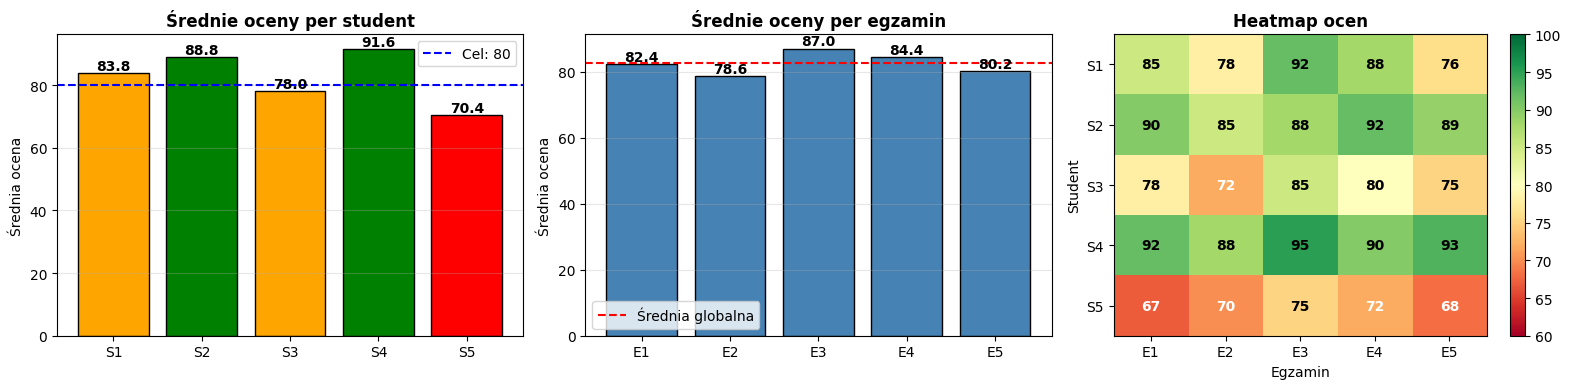

In [11]:
# Vizualizacja: Statystyki exam_scores

import numpy as np
import matplotlib.pyplot as plt

exam_scores = np.array([
    [85, 78, 92, 88, 76],
    [90, 85, 88, 92, 89],
    [78, 72, 85, 80, 75],
    [92, 88, 95, 90, 93],
    [67, 70, 75, 72, 68]
])

student_means = np.mean(exam_scores, axis=1)
exam_means = np.mean(exam_scores, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Średnie per student
students = [f'S{i+1}' for i in range(5)]
colors_students = ['red' if m < 75 else 'orange' if m < 85 else 'green' for 
m in student_means]
axes[0].bar(students, student_means, color=colors_students, 
edgecolor='black')
axes[0].axhline(y=80, color='blue', linestyle='--', label='Cel: 80')
axes[0].set_title('Średnie oceny per student', fontweight='bold', 
fontsize=12)
axes[0].set_ylabel('Średnia ocena')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(student_means):
    axes[0].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# 2. Średnie per egzamin
exams = [f'E{i+1}' for i in range(5)]
axes[1].bar(exams, exam_means, color='steelblue', edgecolor='black')
axes[1].axhline(y=np.mean(exam_scores), color='red', linestyle='--', 
label='Średnia globalna')
axes[1].set_title('Średnie oceny per egzamin', fontweight='bold', 
fontsize=12)
axes[1].set_ylabel('Średnia ocena')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(exam_means):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# 3. Heatmap wszystkich ocen
im = axes[2].imshow(exam_scores, cmap='RdYlGn', vmin=60, vmax=100, 
aspect='auto')
axes[2].set_title('Heatmap ocen', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Egzamin')
axes[2].set_ylabel('Student')
axes[2].set_xticks(range(5))
axes[2].set_xticklabels(exams)
axes[2].set_yticks(range(5))
axes[2].set_yticklabels(students)
plt.colorbar(im, ax=axes[2])

# Dodanie wartości
for i in range(5):
    for j in range(5):
        color = 'white' if exam_scores[i, j] < 75 else 'black'
        axes[2].text(j, i, exam_scores[i, j], ha='center', va='center', color=color, fontweight='bold')
        
plt.tight_layout()
plt.show()

# 4. Broadcasting - automatyczne dopasowanie kształtów

In [12]:
# Przykład 1: Broadcasting ze skalarem

import numpy as np

# Skalar to de facto tablica 0-wymiarowa
arr = np.array([10, 20, 30, 40])
print("Array:", arr, "shape:", arr.shape)  # (4,)

# Mnożenie przez skalar - broadcasting
result = arr * 10
print("arr * 10:", result)  # [100 200 300 400]

# Co się dzieje pod spodem:
# Skalar 10 ma shape ()
# NumPy "rozciąga" go do (4,) → [10, 10, 10, 10]
# Następnie wykonuje element-wise: [10*10, 20*10, 30*10, 40*10]

# To samo działa dla 2D
matrix = np.array([[1, 2, 3], [4, 5, 6]])
print("\nMatrix:")
print(matrix)
print("shape:", matrix.shape)  # (2, 3)

scaled = matrix + 100
print("\nMatrix + 100:")
print(scaled)
# [[101 102 103]
#  [104 105 106]]

Array: [10 20 30 40] shape: (4,)
arr * 10: [100 200 300 400]

Matrix:
[[1 2 3]
 [4 5 6]]
shape: (2, 3)

Matrix + 100:
[[101 102 103]
 [104 105 106]]


In [13]:
# Przykład 2: Broadcasting 1D + 2D

import numpy as np

# Dane: sprzedaż produktów w 4 sklepach przez 3 dni
sales = np.array([
    [100, 150, 200],  # Sklep 1
    [120, 180, 220],  # Sklep 2
    [90, 140, 190],   # Sklep 3
    [110, 160, 210]   # Sklep 4
])

print("Sprzedaż (sklepy x dni):")
print(sales)
print("Shape:", sales.shape)  # (4, 3)

# Chcemy dodać bonus 10, 20, 30 do każdego dnia
daily_bonus = np.array([10, 20, 30])
print("\nBonus dzienny:", daily_bonus)
print("Shape:", daily_bonus.shape)  # (3,)

# Broadcasting: (4, 3) + (3,) → (4, 3)
# NumPy rozciąga (3,) do (1, 3), a potem do (4, 3)
sales_with_bonus = sales + daily_bonus
print("\nSprzedaż z bonusem:")
print(sales_with_bonus)
# [[110 170 230]
#  [130 200 250]
#  [100 160 220]
#  [120 180 240]]

# Inny przykład: mnożnik per sklep
shop_multiplier = np.array([1.1, 1.2, 0.9, 1.0]).reshape(4, 1)  # (4, 1)
print("\nMnożnik per sklep:")
print(shop_multiplier)
print("Shape:", shop_multiplier.shape)

# Broadcasting: (4, 3) * (4, 1) → (4, 3)
adjusted_sales = sales * shop_multiplier
print("\nSprzedaż po korekcie:")
print(adjusted_sales)

Sprzedaż (sklepy x dni):
[[100 150 200]
 [120 180 220]
 [ 90 140 190]
 [110 160 210]]
Shape: (4, 3)

Bonus dzienny: [10 20 30]
Shape: (3,)

Sprzedaż z bonusem:
[[110 170 230]
 [130 200 250]
 [100 160 220]
 [120 180 240]]

Mnożnik per sklep:
[[1.1]
 [1.2]
 [0.9]
 [1. ]]
Shape: (4, 1)

Sprzedaż po korekcie:
[[110. 165. 220.]
 [144. 216. 264.]
 [ 81. 126. 171.]
 [110. 160. 210.]]


In [14]:
# Przykład 3: Broadcasting w praktyce Data Science

import numpy as np

# Dataset: wzrost [cm] i waga [kg] dla 100 osób
np.random.seed(42)
heights = np.random.normal(170, 10, 100)  # Średnia 170cm, std 10
weights = np.random.normal(70, 15, 100)   # Średnia 70kg, std 15

print("Heights shape:", heights.shape)  # (100,)
print("Weights shape:", weights.shape)  # (100,)

# Standaryzacja (z-score normalization): (x - mean) / std
# Klasyczny sposób BEZ broadcastingu
heights_mean = np.mean(heights)
heights_std = np.std(heights)
heights_standardized = (heights - heights_mean) / heights_std

print("\nWysokości standaryzowane (pierwsze 5):", heights_standardized[:5])
print("Średnia po standaryzacji:", np.mean(heights_standardized))  # ~0
print("Std po standaryzacji:", np.std(heights_standardized))       # ~1

# Batch normalization dla macierzy
# Dane: 50 próbek x 4 cechy
data = np.random.randn(50, 4) * 10 + 50
print("\n--- Batch Normalization ---")
print("Data shape:", data.shape)  # (50, 4)

# Obliczamy średnią i std per cecha (axis=0)
mean_per_feature = np.mean(data, axis=0)  # (4,)
std_per_feature = np.std(data, axis=0)    # (4,)

print("Mean per feature:", mean_per_feature)
print("Std per feature:", std_per_feature)

# Standaryzacja z broadcastingiem: (50, 4) - (4,) / (4,)
data_normalized = (data - mean_per_feature) / std_per_feature

print("\nPo normalizacji - średnie per feature:")
print(np.mean(data_normalized, axis=0))  # Prawie [0, 0, 0, 0]
print("Po normalizacji - std per feature:")
print(np.std(data_normalized, axis=0))   # Prawie [1, 1, 1, 1]

# Broadcasting oszczędza pamięć!
# Zamiast powielać mean_per_feature 50 razy → (50, 4)
# NumPy "rozciąga" (4,) do (50, 4) wirtualnie podczas obliczeń

Heights shape: (100,)
Weights shape: (100,)

Wysokości standaryzowane (pierwsze 5): [ 0.66461921 -0.03808894  0.83169721  1.80040643 -0.14420598]
Średnia po standaryzacji: 4.2849057635407915e-15
Std po standaryzacji: 1.0

--- Batch Normalization ---
Data shape: (50, 4)
Mean per feature: [50.70252177 50.68556793 51.86245273 50.18418505]
Std per feature: [10.02151388  9.51487051 10.62458064  9.07525122]

Po normalizacji - średnie per feature:
[ 4.52970994e-16  7.81597009e-16 -5.55111512e-16  1.22124533e-15]
Po normalizacji - std per feature:
[1. 1. 1. 1.]


A shape: (3, 4)
B shape: (4,)

A:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

B: [10 20 30 40]

A + B:
[[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]


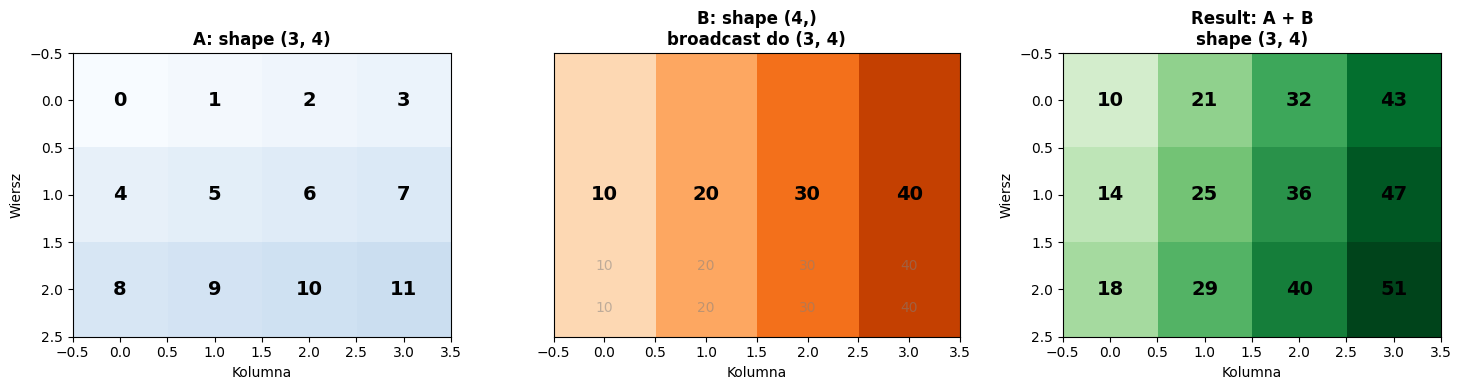

In [15]:
# Wizualizacja: Broadcasting

import numpy as np
import matplotlib.pyplot as plt

# Przykład: (3, 4) + (4,)
A = np.arange(12).reshape(3, 4)
B = np.array([10, 20, 30, 40])

print("A shape:", A.shape)
print("B shape:", B.shape)
print("\nA:")
print(A)
print("\nB:", B)

result = A + B
print("\nA + B:")
print(result)

# Wizualizacja
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# A
im1 = axes[0].imshow(A, cmap='Blues', vmin=0, vmax=50)
axes[0].set_title('A: shape (3, 4)', fontweight='bold', fontsize=12)
for i in range(3):
    for j in range(4):
        axes[0].text(j, i, A[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kolumna')
axes[0].set_ylabel('Wiersz')

# B - pokazany jako wiersz
B_display = B.reshape(1, 4)
axes[1].imshow(B_display, cmap='Oranges', vmin=0, vmax=50, aspect='auto')
axes[1].set_title('B: shape (4,)\nbroadcast do (3, 4)', fontweight='bold', fontsize=12)
for j in range(4):
    axes[1].text(j, 0, B[j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kolumna')
axes[1].set_yticks([])

# Pokazanie rozszerzenia
for i in range(3):
    for j in range(4):
        if i > 0:
            axes[1].text(j, i*0.15 + 0.1, B[j], ha='center', va='center',
                        fontsize=10, color='gray', alpha=0.5)
# Result
im3 = axes[2].imshow(result, cmap='Greens', vmin=0, vmax=50)
axes[2].set_title('Result: A + B\nshape (3, 4)', fontweight='bold', fontsize=12)
for i in range(3):
    for j in range(4):
        axes[2].text(j, i, result[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Kolumna')
axes[2].set_ylabel('Wiersz')

plt.tight_layout()
plt.show()


# 🌱 Aspekt środowiskowy

In [16]:
# Przykład: Porównanie zużycia czasu i pamięci

import numpy as np
import time

# Dataset: 10 milionów wartości
size = 10_000_000
data = np.random.randn(size)

# Metoda 1: Pętla Python (WOLNO, dużo energii)
start = time.time()
result_loop = []
for x in data:
    result_loop.append(x ** 2)
time_loop = time.time() - start

# Metoda 2: NumPy wektoryzacja (SZYBKO, mało energii)
start = time.time()
result_numpy = data ** 2
time_numpy = time.time() - start

print(f"Czas pętla Python: {time_loop:.3f}s")
print(f"Czas NumPy: {time_numpy:.4f}s")
print(f"Przyspieszenie: {time_loop/time_numpy:.1f}x")
print(f"\nOszczędność czasu: {(time_loop - time_numpy):.3f}s")
print(f"Przy 1000 takich operacjach dziennie:")
print(f"  - Oszczędność czasu: {(time_loop - time_numpy) * 1000 / 60:.1f} minut/dzień")
print(f"  - Mniej zużycia energii procesora i chłodzenia")

# Oszczędność pamięci: view vs copy
arr = np.arange(1_000_000)
slice_view = arr[::2]  # View - 0 dodatkowej pamięci
slice_copy = arr[::2].copy()  # Copy - duplikacja danych

print(f"\nRozmiar oryginalnej tablicy: {arr.nbytes / 1024:.1f} KB")
print(f"Rozmiar view (slice): 0 KB dodatkowych (wskaźnik do oryginału)")
print(f"Rozmiar copy: {slice_copy.nbytes / 1024:.1f} KB dodatkowych")

Czas pętla Python: 1.089s
Czas NumPy: 0.0121s
Przyspieszenie: 90.3x

Oszczędność czasu: 1.076s
Przy 1000 takich operacjach dziennie:
  - Oszczędność czasu: 17.9 minut/dzień
  - Mniej zużycia energii procesora i chłodzenia

Rozmiar oryginalnej tablicy: 7812.5 KB
Rozmiar view (slice): 0 KB dodatkowych (wskaźnik do oryginału)
Rozmiar copy: 3906.2 KB dodatkowych


# 📊 Praca z Prawdziwymi Danymi

In [17]:
# Dataset: Iris Dataset

import numpy as np

# Wczytanie danych Iris (ręcznie utworzone dla demonstracji)
# W praktyce: from sklearn.datasets import load_iris
# Tutaj: uproszczona wersja (pierwsze 10 próbek każdego gatunku)
# Format: [sepal_length, sepal_width, petal_length, petal_width]
# Gatunki: 0 = setosa, 1 = versicolor, 2 = virginica

iris_data = np.array([
# Setosa (0)
    [5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2],
    [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2], [5.4, 3.9, 1.7, 0.4],
    [4.6, 3.4, 1.4, 0.3], [5.0, 3.4, 1.5, 0.2], [4.4, 2.9, 1.4, 0.2],
    [4.9, 3.1, 1.5, 0.1],
    # Versicolor (1)
    [7.0, 3.2, 4.7, 1.4], [6.4, 3.2, 4.5, 1.5], [6.9, 3.1, 4.9, 1.5],
    [5.5, 2.3, 4.0, 1.3], [6.5, 2.8, 4.6, 1.5], [5.7, 2.8, 4.5, 1.3],
    [6.3, 3.3, 4.7, 1.6], [4.9, 2.4, 3.3, 1.0], [6.6, 2.9, 4.6, 1.3],
    [5.2, 2.7, 3.9, 1.4],
    # Virginica (2)
    [6.3, 3.3, 6.0, 2.5], [5.8, 2.7, 5.1, 1.9], [7.1, 3.0, 5.9, 2.1],
    [6.3, 2.9, 5.6, 1.8], [6.5, 3.0, 5.8, 2.2], [7.6, 3.0, 6.6, 2.1],
    [4.9, 2.5, 4.5, 1.7], [7.3, 2.9, 6.3, 1.8], [6.7, 2.5, 5.8, 1.8],
    [7.2, 3.6, 6.1, 2.5]
])

iris_labels = np.array([0]*10 + [1]*10 + [2]*10)

print("Iris dataset shape:", iris_data.shape)  # (30, 4)
print("Labels shape:", iris_labels.shape)      # (30,)

# Podstawowe statystyki
print("\n--- Statystyki per cecha ---")
feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
for i, name in enumerate(feature_names):
    print(f"{name}:")
    print(f"  Mean: {np.mean(iris_data[:, i]):.2f}")
    print(f"  Std: {np.std(iris_data[:, i]):.2f}")
    print(f"  Min: {np.min(iris_data[:, i]):.2f}")
    print(f"  Max: {np.max(iris_data[:, i]):.2f}")

Iris dataset shape: (30, 4)
Labels shape: (30,)

--- Statystyki per cecha ---
Sepal Length:
  Mean: 5.84
  Std: 0.95
  Min: 4.40
  Max: 7.60
Sepal Width:
  Mean: 3.04
  Std: 0.37
  Min: 2.30
  Max: 3.90
Petal Length:
  Mean: 3.86
  Std: 1.85
  Min: 1.30
  Max: 6.60
Petal Width:
  Mean: 1.21
  Std: 0.78
  Min: 0.10
  Max: 2.50


In [18]:
# Analiza i Preprocessing

import numpy as np

# Normalizacja Min-Max: (x - min) / (max - min) → [0, 1]
min_vals = np.min(iris_data, axis=0)  # (4,) - min per cecha
max_vals = np.max(iris_data, axis=0)  # (4,)

# Broadcasting: (30, 4) - (4,) / (4,)
iris_normalized = (iris_data - min_vals) / (max_vals - min_vals)

print("Dane po normalizacji (pierwsze 5):")
print(iris_normalized[:5])
print("\nMin per feature:", np.min(iris_normalized, axis=0))  # ~[0, 0, 0, 0]
print("Max per feature:", np.max(iris_normalized, axis=0))    # ~[1, 1, 1, 1]

# Standaryzacja: (x - mean) / std → mean=0, std=1
mean_vals = np.mean(iris_data, axis=0)
std_vals = np.std(iris_data, axis=0)

iris_standardized = (iris_data - mean_vals) / std_vals

print("\n--- Po standaryzacji ---")
print("Mean per feature:", np.mean(iris_standardized, axis=0))  # ~[0, 0, 0, 0]
print("Std per feature:", np.std(iris_standardized, axis=0))    # ~[1, 1, 1, 1]

# Filtrowanie: Tylko próbki z Petal Length > 4.0
mask = iris_data[:, 2] > 4.0
filtered_data = iris_data[mask]
filtered_labels = iris_labels[mask]
print(f"\nPróbki z Petal Length > 4.0: {filtered_data.shape[0]}/{iris_data.shape[0]}")
print("Gatunki w filtrowanych danych:", np.unique(filtered_labels))


Dane po normalizacji (pierwsze 5):
[[0.21875    0.75       0.01886792 0.04166667]
 [0.15625    0.4375     0.01886792 0.04166667]
 [0.09375    0.5625     0.         0.04166667]
 [0.0625     0.5        0.03773585 0.04166667]
 [0.1875     0.8125     0.01886792 0.04166667]]

Min per feature: [0. 0. 0. 0.]
Max per feature: [1. 1. 1. 1.]

--- Po standaryzacji ---
Mean per feature: [ 6.36527867e-16 -5.92118946e-17  4.07081776e-16 -1.55431223e-16]
Std per feature: [1. 1. 1. 1.]

Próbki z Petal Length > 4.0: 17/30
Gatunki w filtrowanych danych: [1 2]


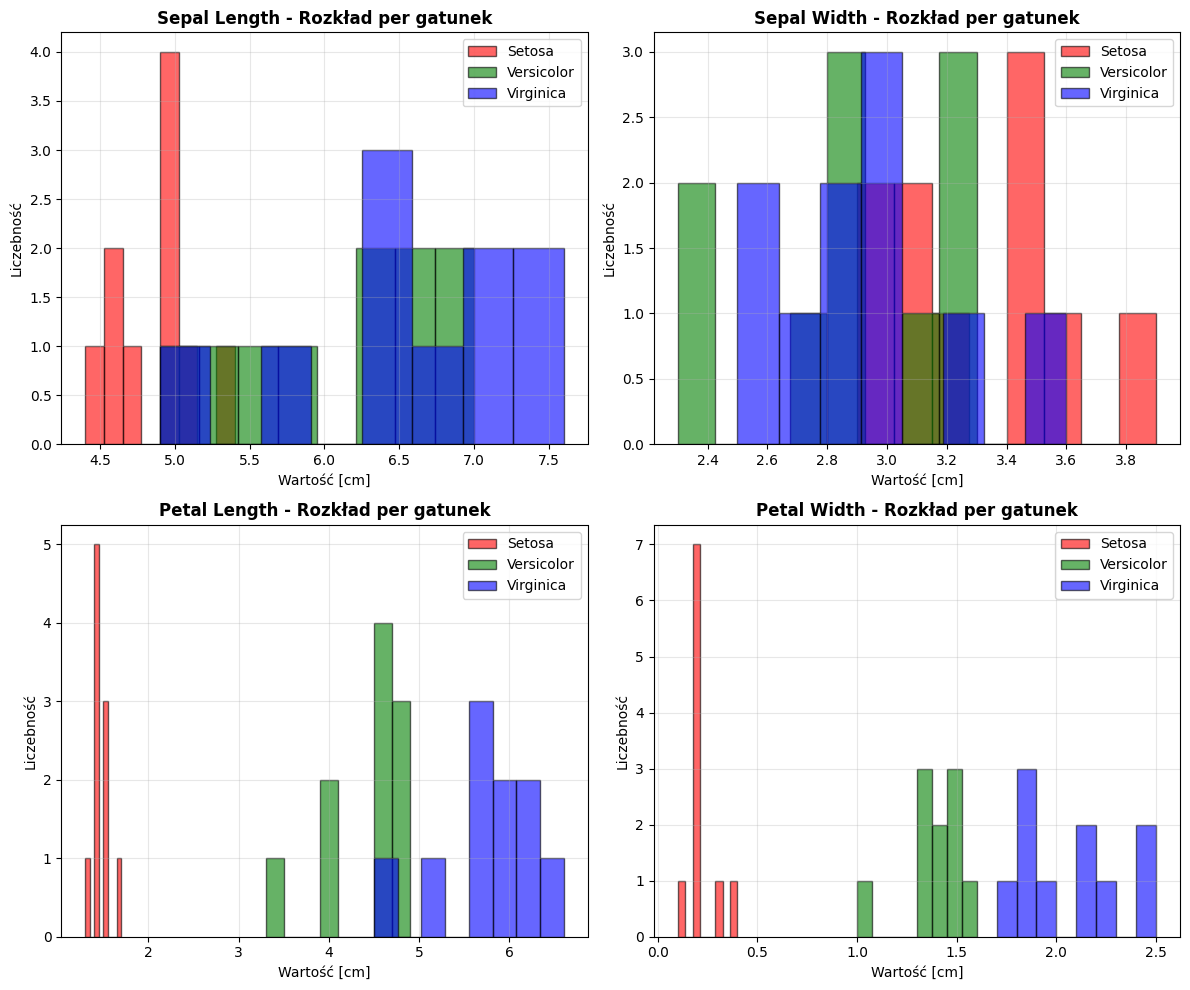

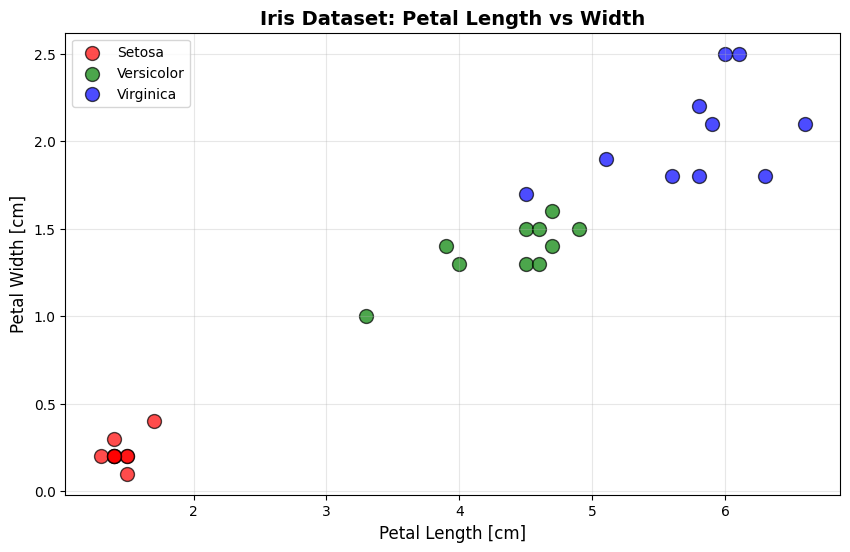


--- Macierz korelacji ---
[[ 1.         -0.01841756  0.87656767  0.80610799]
 [-0.01841756  1.         -0.33847608 -0.28902677]
 [ 0.87656767 -0.33847608  1.          0.97455592]
 [ 0.80610799 -0.28902677  0.97455592  1.        ]]


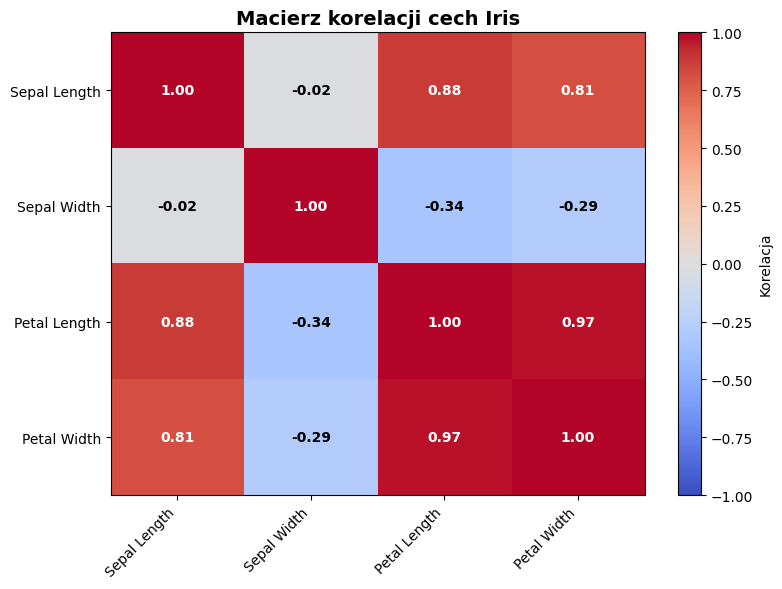

In [19]:
# Wizualizacja Eksploracyjna

import numpy as np
import matplotlib.pyplot as plt

# Wizualizacja rozkładu cech
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

colors = ['red', 'green', 'blue']
species = ['Setosa', 'Versicolor', 'Virginica']

for i, name in enumerate(feature_names):
    for species_idx in range(3):
        species_data = iris_data[iris_labels == species_idx, i]
        axes[i].hist(species_data, alpha=0.6, label=species[species_idx], color=colors[species_idx], bins=8, edgecolor='black')
    axes[i].set_title(f'{name} - Rozkład per gatunek', fontweight='bold')
    axes[i].set_xlabel('Wartość [cm]')
    axes[i].set_ylabel('Liczebność')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot: Petal Length vs Petal Width
plt.figure(figsize=(10, 6))
for species_idx in range(3):
    mask = iris_labels == species_idx
    plt.scatter(iris_data[mask, 2], iris_data[mask, 3], label=species[species_idx], color=colors[species_idx], s=100, edgecolor='black', alpha=0.7)
plt.xlabel('Petal Length [cm]', fontsize=12)
plt.ylabel('Petal Width [cm]', fontsize=12)
plt.title('Iris Dataset: Petal Length vs Width', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Macierz korelacji (ręczna implementacja)
# Korelacja Pearsona: cov(X, Y) / (std(X) * std(Y))
print("\n--- Macierz korelacji ---")
n_features = iris_data.shape[1]
corr_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        if i == j:
            corr_matrix[i, j] = 1.0
        else:
            # Korelacja
            x = iris_data[:, i]
            y = iris_data[:, j]
            corr = np.sum((x - np.mean(x)) * (y - np.mean(y))) / (len(x) * np.std(x) * np.std(y))
            corr_matrix[i, j] = corr

print(corr_matrix)

# Wizualizacja macierzy korelacji
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Korelacja')
plt.xticks(range(n_features), feature_names, rotation=45, ha='right')
plt.yticks(range(n_features), feature_names)
plt.title('Macierz korelacji cech Iris', fontweight='bold', fontsize=14)
for i in range(n_features):
    for j in range(n_features):
        plt.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black', fontweight='bold')
plt.tight_layout()
plt.show()